<div style="text-align:center;">
<h1 style ="color:#1f77b4;font-size:40px;">🏏 IPL DATA ANALYSIS </h1>
</div>


<div style="background:#f8f9fa;padding:18px;border-radius;10px;margin-top:10px;">
<h2 style="color:#ff7f0e;">🎯Objective</h2>
<p style="font-size:16px;color:#333;">
 Analyze IPL match and ball-by-ball datasets to uncover insights related to batting performances, bowling efficiency, toss impact,  team success, and fielding records using python
</p>
</div>


<div style ="background:#f8f9fa;padding:18px;border-radius:10px;margin-top:10px;">
<h2 style="color:#2ca02c";>📂 Dataset information</h2>
<p style="color:#333;"><b>matches.csv</b> -> match-level data such as teams, toss-winner, vennue, result.</p>
<p style="color:#333;"><b>deliveries.csv</b> -> ball-by-ball data including batsman runs, wickets, bowlers.</p>
</div>

<div style ="background:#eeef6ff;padding:15px;border-radius:10px;margin-top:10px;">
<h2 style="color:#1f77b4;">📚Import libraries</h2>
<p style="font-size:16px;color:#333;">
   * pandas for data manipulation and analysis,<br>
   * matplotlib for data visualization and charts.
</p>
</div>

In [12]:
import pandas as pd 
matches = pd.read_csv("matches.csv")
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [11]:
import pandas as pd 
deliveries = pd.read_csv("deliveries.csv")
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


### query 1: which team won maximum matches while chasing?

In [3]:

chasing_wins = matches[matches["win_by_wickets"]>0]
print("team with the most wins as a chasing team:")
chasing_wins["winner"].value_counts().head(1)



team with the most wins as a chasing team:


winner
Kolkata Knight Riders    56
Name: count, dtype: int64

### query 2: which team lost maximum matches while chasing?

In [44]:

chasing_loss = matches[matches["win_by_runs"]>0]
print("team with the most losses as a chasing team:")
chasing_loss["team2"].value_counts().head(1)

team with the most losses as a chasing team:


team2
Delhi Daredevils    47
Name: count, dtype: int64

### query 3: what is the best toss decision for each ground?

In [41]:

best_toss=toss_result.loc[toss_result.groupby("venue")["winner"].idxmax()]
print("Best toss decision for each ground:")
best_toss

Best toss decision for each ground:


,venue,toss_decision,winner
0,ACA-VDCA Stadium,field,2
2,Barabati Stadium,field,5
3,Brabourne Stadium,bat,6
5,Buffalo Park,bat,3
6,De Beers Diamond Oval,bat,2
9,Dr DY Patil Sports Academy,field,10
11,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,field,6
13,Dubai International Cricket Stadium,field,4
15,Eden Gardens,field,49
17,Feroz Shah Kotla,field,39


### query 4: which player won maximum MoM awars while chasing

In [5]:

mom_chasing = matches[matches["win_by_wickets"]>0]
mom_result = mom_chasing["player_of_match"].value_counts().head(1)
print("player who won the maximmum number of Man of the Match awards while chasing:")
mom_result

player who won the maximmum number of Man of the Match awards while chasing:


player_of_match
YK Pathan    11
Name: count, dtype: int64

### query 5: which player faced maximum dot balls?

In [12]:

dot_balls = deliveries[deliveries["batsman_runs"]==0]
dot_result = dot_balls["batsman"].value_counts().head(1)
print("Player who played the maximum number of dot balls:")
print(dot_result)

Player who played the maximum number of dot balls:
batsman
V Kohli    1493
Name: count, dtype: int64


### query 6: which batsman came to crease but didnt face a delivery 

In [36]:
#batsman came to crease but didnt face a delivery 
came_to_bat = deliveries["non_striker"].unique()
faced_ball = deliveries["batsman"].unique()
never_faced = set(came_to_bat)-set(faced_ball)
print("Batsman who came to crease but never faced a ball:")
print(never_faced)

Batsman who came to crease but never faced a ball:
{'A Nel', 'TP Sudhindra', 'C Ganapathy', 'BW Hilfenhaus'}


### query 7: which bowler got hit for maximum number of 1s, 2s, 3s, 4s, 6s 

In [13]:

for runs in [1,2,3,4,6]:
    result = deliveries[deliveries["batsman_runs"]==runs]["bowler"].value_counts().head(1)
    print("Bowler hit for maximum",runs,"runs:")
    print (result)
    print()

Bowler hit for maximum 1 runs:
bowler
Harbhajan Singh    1465
Name: count, dtype: int64

Bowler hit for maximum 2 runs:
bowler
A Mishra    232
Name: count, dtype: int64

Bowler hit for maximum 3 runs:
bowler
P Kumar    16
Name: count, dtype: int64

Bowler hit for maximum 4 runs:
bowler
UT Yadav    384
Name: count, dtype: int64

Bowler hit for maximum 6 runs:
bowler
PP Chawla    171
Name: count, dtype: int64



### query 8: which batsman got stumped maximum times 

In [66]:

stumped_out = deliveries[deliveries["dismissal_kind"]=="stumped"]
print("batsman who got stumped maximum number of times:")
stumped_out["player_dismissed"].value_counts().head(1)

batsman who got stumped maximum number of times:


player_dismissed
SK Raina    8
Name: count, dtype: int64

### query 9: which batsman has been a part of maximum runouts as a non striker 

In [67]:

runout = deliveries[deliveries["dismissal_kind"]=="run out"]
print("non striker part of maximum run outs:")
runout["non_striker"].value_counts().head(1)

non striker part of maximum run outs:


non_striker
SK Raina    16
Name: count, dtype: int64

### query 10: which venue hosted the maximum matches 

In [68]:

print("the venue which hosted the maximum matches:")
matches["venue"].value_counts().head(1)

the venue which hosted the maximum matches:


venue
Eden Gardens    77
Name: count, dtype: int64

### query 11: which batsman has hit the maximum runs

In [69]:

runs = deliveries[deliveries["batsman_runs"].notna()]
print("batsman with the maximum runs:")
runs["batsman"].value_counts().head(1)


batsman with the maximum runs:


batsman
V Kohli    4211
Name: count, dtype: int64

### query 12: which bowler took maximum wickets 

In [17]:

wickets = deliveries[deliveries["dismissal_kind"].notna()]
print("bowler with the maximum number of wickets:")
wickets["bowler"].value_counts().head(1)

bowler with the maximum number of wickets:


bowler
SL Malinga    188
Name: count, dtype: int64

### query 13: Top 10 batsman with the highest strike rate in descending order 

In [19]:

runs = deliveries.groupby("batsman")["batsman_runs"].sum()
balls = deliveries.groupby("batsman").size()

strike_rate = ((runs/balls)*100)
result = strike_rate[balls>=2000].sort_values(ascending=False)
print("batsmans with the highest strike rate in descending order:")
result.head(10)

batsmans with the highest strike rate in descending order:


batsman
AB de Villiers    148.740343
CH Gayle          145.640370
DA Warner         139.523249
YK Pathan         138.860326
SR Watson         136.945813
MS Dhoni          134.930681
SK Raina          133.902077
V Kohli           129.042983
RG Sharma         128.773585
KD Karthik        127.612457
dtype: float64

### query 14: Top 10 bowlers with the lowest economy rate in ascending order

In [77]:

runs = deliveries.groupby("bowler")["total_runs"].sum()
balls = deliveries.groupby("bowler").size()

economy = (runs / (balls/6))
result = economy[balls>=160].sort_values(ascending=True)
print("bowlers with the lowest economy rate:")
result.head(10)

bowlers with the lowest economy rate:


bowler
Sohail Tanvir      6.226415
A Chandila         6.282051
L Ngidi            6.441718
SMSM Senanayake    6.492308
SM Pollock         6.578571
J Yadav            6.584071
A Kumble           6.646999
DW Steyn           6.671500
GD McGrath         6.674772
M Muralitharan     6.698292
dtype: float64

### query 15: Top 10 batsman who hit the maximum number of sixes in death overs

In [90]:

death_overs = deliveries[deliveries["over"]>=16]
sixes = death_overs[death_overs["batsman_runs"]==6]
print("batsman with most number of sixes in death overs:")
sixes["batsman"].value_counts().head(10)

batsman with most number of sixes in death overs:


batsman
MS Dhoni          153
AB de Villiers    106
KA Pollard        106
RG Sharma          88
AD Russell         76
V Kohli            74
Yuvraj Singh       68
YK Pathan          56
DA Miller          52
HH Pandya          51
Name: count, dtype: int64

### query 16: Top 10 bowlers with the maximum wickets in death overs

In [35]:
death_over = deliveries[deliveries["over"]>=16]
print("bowlers who took the most wickets in death overs")
death_over[death_over["dismissal_kind"].isin(["bowled","caught","stumped","caught and bowled", "hit wicket"])]["bowler"].value_counts().head(10)


bowlers who took the most wickets in death overs


bowler
SL Malinga       100
DJ Bravo          87
B Kumar           75
A Nehra           54
SP Narine         53
UT Yadav          48
DW Steyn          48
R Vinay Kumar     45
RP Singh          44
JJ Bumrah         44
Name: count, dtype: int64

### query 17: which batting pair had the highest partnership in powerplay overs?

In [33]:
powerplay = deliveries[deliveries["over"]<=6]
powerplay["pair"] = powerplay["batsman"] + "&" + powerplay["non_striker"]
print("batting pairs with the highest partnership:")
powerplay.groupby("pair")["total_runs"].sum().sort_values(ascending=False).head(10)

batting pairs with the highest partnership:


C:\Users\YASH GUPTA\AppData\Local\Temp\ipykernel_22480\1706846403.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  powerplay["pair"] = powerplay["batsman"] + "&" + powerplay["non_striker"]


pair
DA Warner&S Dhawan      1068
RV Uthappa&G Gambhir     739
CH Gayle&V Kohli         698
S Dhawan&DA Warner       663
DR Smith&BB McCullum     607
G Gambhir&RV Uthappa     524
V Kohli&CH Gayle         524
MEK Hussey&M Vijay       488
BB McCullum&DR Smith     486
R Dravid&AM Rahane       480
Name: total_runs, dtype: int64

### query 18: which team won the maximum matches after losing toss?

In [100]:

lost_toss = matches[matches["toss_winner"]!=matches["winner"]]
print("teams that won the most after losing toss:")
lost_toss["winner"].value_counts().head(10)

teams that won the most after losing toss:


winner
Mumbai Indians                 53
Kings XI Punjab                47
Royal Challengers Bangalore    43
Chennai Super Kings            43
Kolkata Knight Riders          39
Sunrisers Hyderabad            35
Rajasthan Royals               33
Delhi Daredevils               32
Deccan Chargers                10
Pune Warriors                   9
Name: count, dtype: int64

### query 19: which player took the most catches as an outfield player

In [110]:

wicket_keepers = deliveries[deliveries["dismissal_kind"]=="stumped"]["fielder"].dropna().unique()

catches = deliveries[deliveries["dismissal_kind"]=="caught"]

result = catches[~catches["fielder"].isin(wicket_keepers)]
print("fielders who took the most catches in ipl history (excluding wicket keepers):")
result["fielder"].value_counts().head(10)


fielders who took the most catches in ipl history (excluding wicket keepers):


fielder
SK Raina      99
RG Sharma     82
KA Pollard    76
V Kohli       73
S Dhawan      68
DJ Bravo      66
MK Pandey     63
RA Jadeja     60
AM Rahane     54
DA Warner     54
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(10,5)


### query 20: Top 10 winning teams 

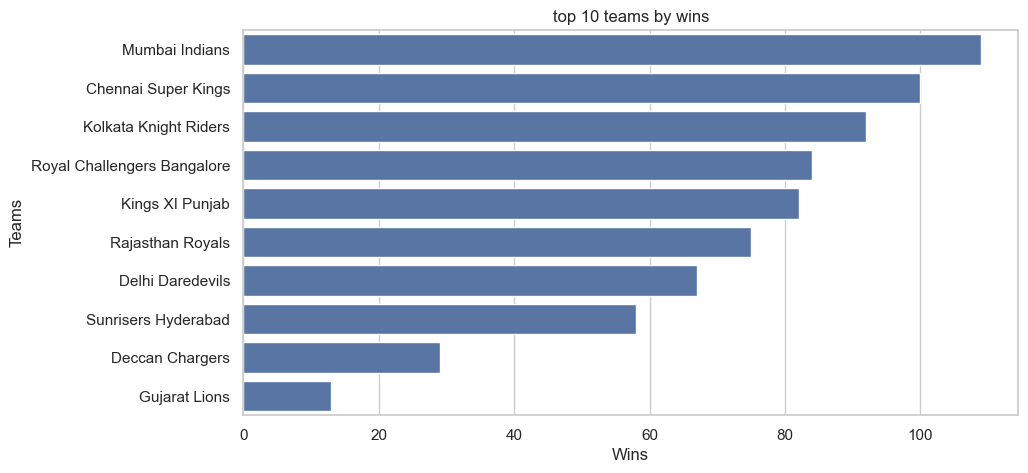

In [13]:
top_teams = matches["winner"].value_counts().head(10)
sns.barplot(x=top_teams.values,
            y=top_teams.index)
plt.title("top 10 teams by wins")
plt.xlabel("Wins")
plt.ylabel("Teams")
plt.show()

### query 21: matches per season

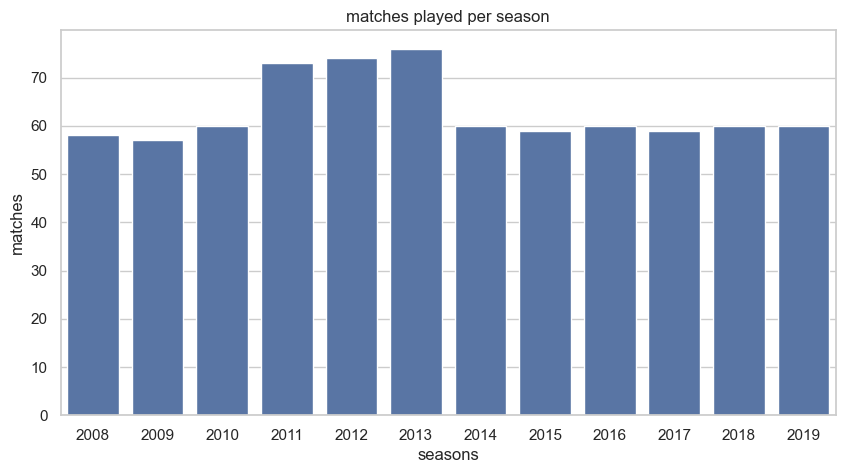

In [14]:
sns.countplot(x="season",data=matches)
plt.title("matches played per season")
plt.xlabel("seasons")
plt.ylabel("matches")
plt.show()

### query 22: Toss decision pie chart

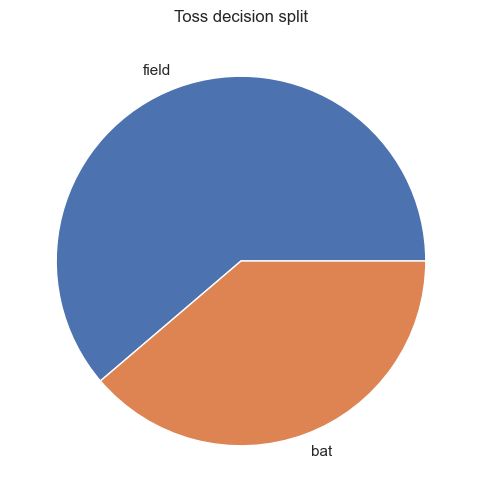

In [18]:
toss_count = matches["toss_decision"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(toss_count.values,
        labels=toss_count.index,
       )
plt.title("Toss decision split")
plt.show()

### query 23: number of venues used per season

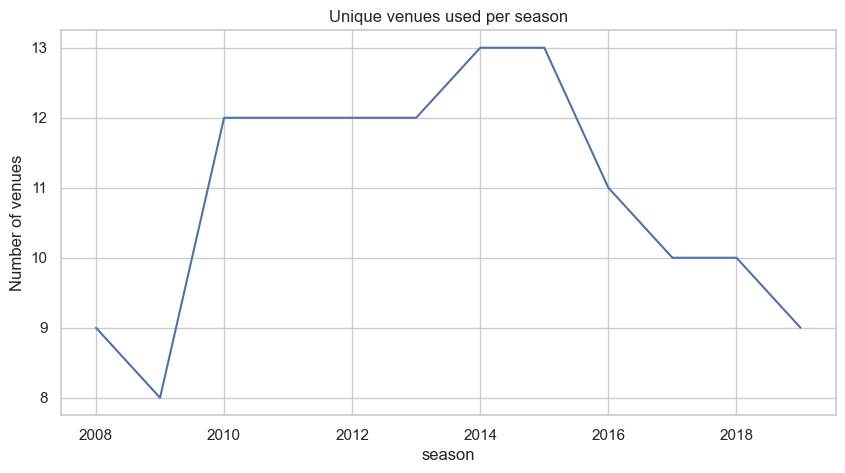

In [20]:
venue = matches.groupby("season")["venue"].nunique().reset_index()

sns.lineplot(data=venue,x="season",y="venue",)
plt.title("Unique venues used per season")
plt.xlabel("season")
plt.ylabel("Number of venues")
plt.show()